<h1>Install and Import Libraries

In [33]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

import joblib

<h1>Import CSV Data File and Convert to Pandas Dataset

In [34]:
df = pd.read_csv('credit_risk_dataset.csv')

<h1>Head and Tail

In [35]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [36]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


<h1>Exploratory Data Analysis

In [37]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Loan Grade, Person Home Ownership, Loan Intent, Loan Status, cb_person_default_on_file: Counts

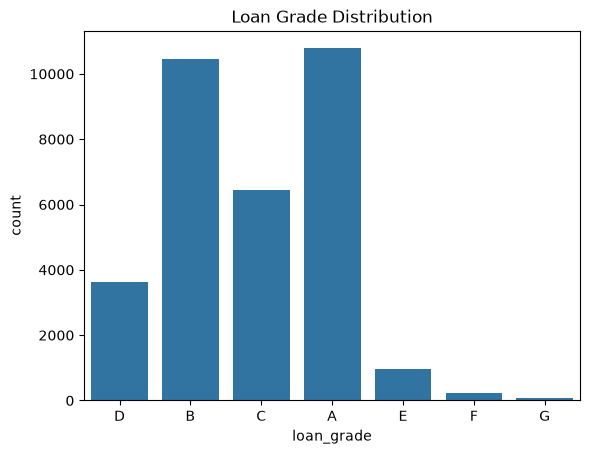

loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64


In [38]:
#loan grade distribution
sns.countplot(x='loan_grade', data=df)
plt.title('Loan Grade Distribution')
plt.show()
count_by_grade = df['loan_grade'].value_counts()
print(count_by_grade)

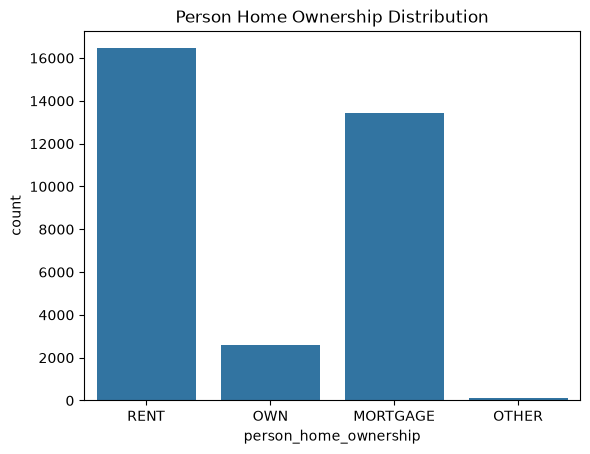

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64


In [39]:
#person home ownership distribution
sns.countplot(x='person_home_ownership', data=df)
plt.title('Person Home Ownership Distribution')
plt.show()
count_by_home_ownership = df['person_home_ownership'].value_counts()
print(count_by_home_ownership)

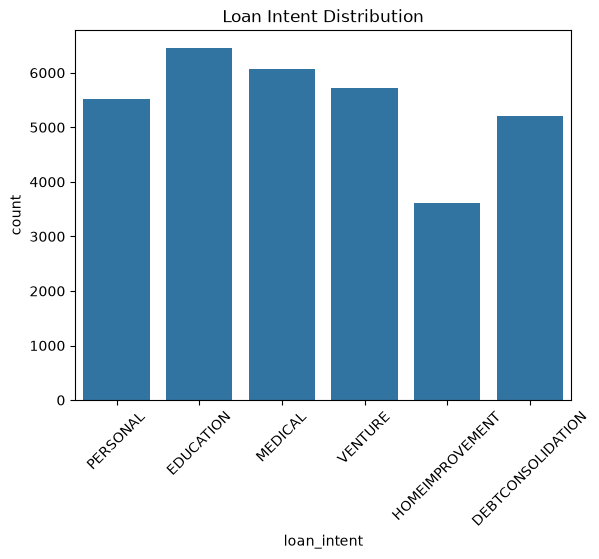

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64


In [40]:
#loan intent distribution
sns.countplot(x='loan_intent', data=df)
plt.title('Loan Intent Distribution')
plt.xticks(rotation=45)
plt.show()
count_by_loan_intent = df['loan_intent'].value_counts()
print(count_by_loan_intent)

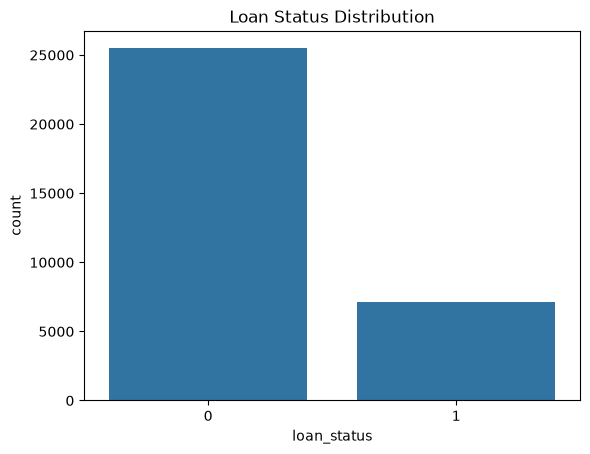

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [41]:
#loan status distribution
sns.countplot(x='loan_status', data=df)
plt.title('Loan Status Distribution')
plt.show()
count_by_loan_status = df['loan_status'].value_counts()
print(count_by_loan_status)

In [42]:
#percentage of loans appproved vs rejected
loan_status_counts = df['loan_status'].value_counts()
print(loan_status_counts)

loan_status
0    25473
1     7108
Name: count, dtype: int64


In [43]:
#percentage of repaid vs defaulted loans
# loan_status is encoded as integers: 0 = approved (loan repaid), 1 = rejected (defaulted)
total_loans = len(df)
approved_loans = loan_status_counts.get(0, 0)
rejected_loans = loan_status_counts.get(1, 0)
approved_percentage = (approved_loans / total_loans) * 100
rejected_percentage = (rejected_loans / total_loans) * 100
print(f"Approved Loans: {approved_percentage:.2f}%")
print(f"Rejected Loans: {rejected_percentage:.2f}%")

Approved Loans: 78.18%
Rejected Loans: 21.82%


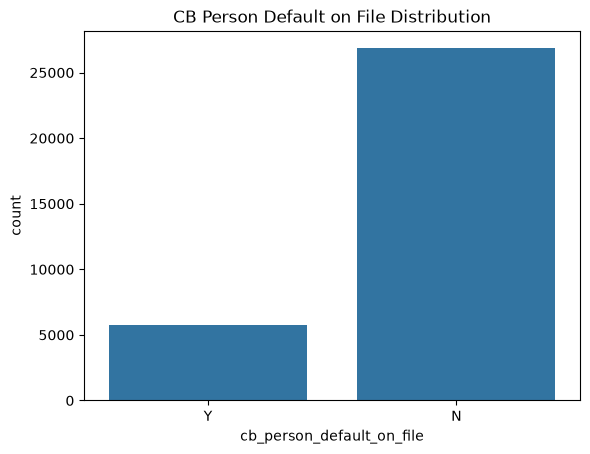

cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64


In [44]:
#cb person default on file
sns.countplot(x='cb_person_default_on_file', data=df)
plt.title('CB Person Default on File Distribution')
plt.show()
count_by_default_on_file = df['cb_person_default_on_file'].value_counts()
print(count_by_default_on_file)

In [45]:
#percentage of cb person default on file
default_on_file_counts = df['cb_person_default_on_file'].value_counts()
total_records = len(df)
default_on_file_percentage = (default_on_file_counts / total_records) * 100
print(default_on_file_percentage.map("{:.2f}%".format))

cb_person_default_on_file
N    82.37%
Y    17.63%
Name: count, dtype: str


Duplicates and Cleaning

In [46]:
df = df.drop_duplicates()
df.shape
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

loan_int_rate        3095
person_emp_length     887
dtype: int64

Feature Selection: Model without loan grade

In [47]:
features = [
    "person_age",
    "person_income",
    "person_home_ownership",
    "person_emp_length",
    "loan_intent",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_default_on_file",
    "cb_person_cred_hist_length"
]

target = "loan_status"

x = df[features]
y = df[target]

<h1>Training Models and Model Evaluation

Train-Test Split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape

((25932, 10), (6484, 10))

Preprocessing Pipeline

In [49]:
numeric_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = x.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features, categorical_features

/var/folders/j0/k5lhywns4q3b0q7rl9_z12c00000gn/T/ipykernel_13344/82777511.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(include=["object", "category"]).columns.tolist()


(['person_age',
  'person_income',
  'person_emp_length',
  'loan_amnt',
  'loan_int_rate',
  'loan_percent_income',
  'cb_person_cred_hist_length'],
 ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file'])

In [50]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Baseline Models

In [51]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [52]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    clf.fit(X_train, y_train)
    
    y_pred = clf.predict(X_test)
    
    if hasattr(clf.named_steps["model"], "predict_proba"):
        y_proba = clf.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
    else:
        roc_auc = None
        pr_auc = None
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    })

results_df = pd.DataFrame(results).sort_values(by="roc_auc", ascending=False)
results_df

,model,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.916255,0.871077,0.724260,0.790913,0.925500,0.866253
2,Gradient Boosting,0.919648,0.949850,0.667842,0.784265,0.918395,0.862030
0,Logistic Regression,0.774830,0.490583,0.771509,0.599781,0.852372,0.680148


Best Model Selection

In [53]:
best_model_name = results_df.iloc[0]["model"]
best_model_name

'Random Forest'

In [54]:
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [55]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5066
           1       0.87      0.72      0.79      1418

    accuracy                           0.92      6484
   macro avg       0.90      0.85      0.87      6484
weighted avg       0.91      0.92      0.91      6484



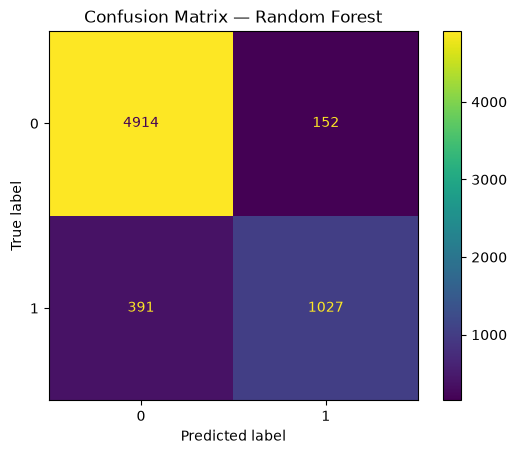

In [56]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

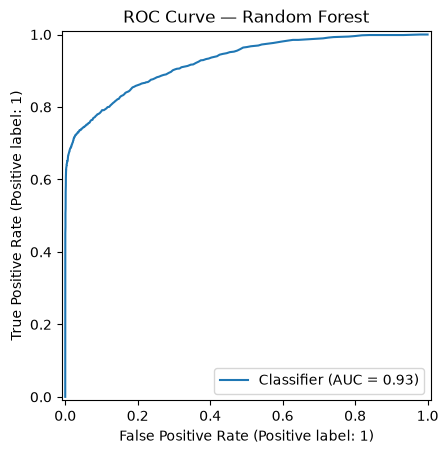

In [57]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"ROC Curve — {best_model_name}")
plt.show()

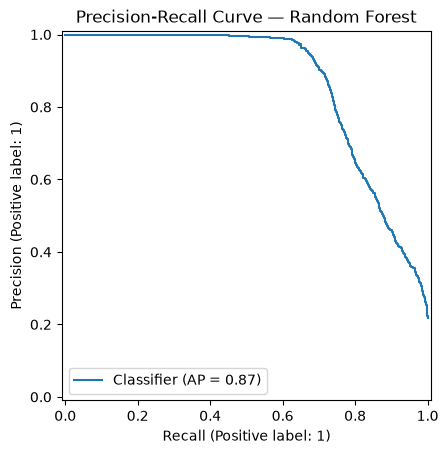

In [58]:
PrecisionRecallDisplay.from_predictions(y_test, y_proba)
plt.title(f"Precision-Recall Curve — {best_model_name}")
plt.show()

<h1>Risk Tier Function

In [59]:
def risk_tier(default_probability):
    if default_probability < 0.10:
        return "Low Risk"
    elif default_probability < 0.25:
        return "Moderate Risk"
    elif default_probability < 0.50:
        return "High Risk"
    else:
        return "Very High Risk"

In [60]:
#example user
sample_user = X_test.iloc[[0]]

default_probability = best_model.predict_proba(sample_user)[0, 1]
tier = risk_tier(default_probability)

default_probability, tier

(np.float64(0.23333333333333334), 'Moderate Risk')